In [1]:
import sys
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("--- Environment Check ---")
print(f"Python Version: {sys.version}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
print("------------------------")

--- Environment Check ---
Python Version: 3.10.22 | packaged by Anaconda, Inc. | (main, Oct  1 2026, 20:15:38) [MSC v.1942 64 bit (AMD64)]
PyTorch Version: 2.12.0.dev20260408+cu128
CUDA Available: True
GPU Device: NVIDIA GeForce RTX 5060 Laptop GPU
------------------------


Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\sagal\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Sample room image saved to: ../data/sample_images/living_room.jpg

image 1/1 c:\Users\sagal\Desktop\Let us build\AI_interior_design\research\..\data\sample_images\living_room.jpg: 352x640 3 chairs, 3 couchs, 3 potted plants, 11.3ms
Speed: 44.5ms preprocess, 11.3ms inference, 20.0ms postprocess per image at shape (1, 3, 352, 640)
Detected: potted plant (Confidence: 0.81)
Detected: chair (Confidence: 0.74)
Detected: couch (Confidence: 0.68)
Detected: potted plant (Confidence: 0.67)
Detected: chair (Confidence: 0.61)
Detected: potted plant (Confidence: 0.53)
Detected: chair (Confidence: 0.41)
Detected: couch (Confidence: 0.41)
Detected: couch (Confidence: 0.32)


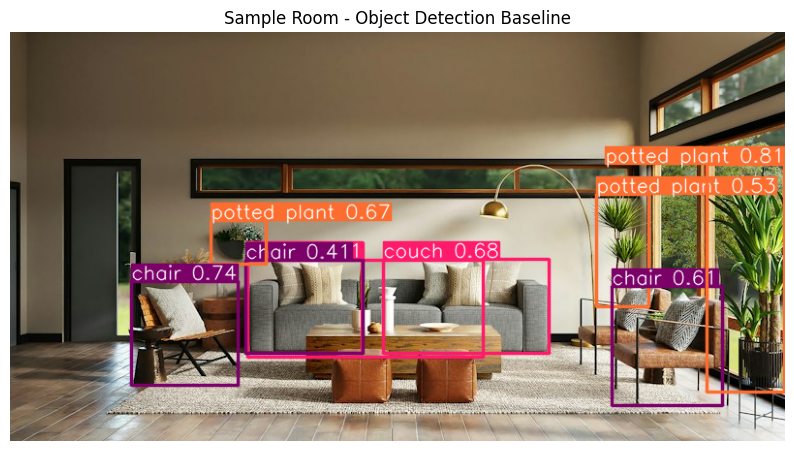

In [2]:
import urllib.request
from ultralytics import YOLO

# Create data directory if it doesn't exist
os.makedirs("../data/sample_images", exist_ok=True)
sample_img_path = "../data/sample_images/living_room.jpg"

# Download a sample living room image for testing
url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg"  # temporary test image
# Let's grab a real interior design room image
room_url = "https://images.unsplash.com/photo-1618221195710-dd6b41faaea6?w=800&auto=format&fit=crop"
urllib.request.urlretrieve(room_url, sample_img_path)

print(f"Sample room image saved to: {sample_img_path}")

# Initialize object detection model on GPU
model = YOLO("yolov8n.pt")  # Nano model for quick testing

# Run inference
results = model(sample_img_path, device="cuda")

# Display detected objects
for r in results:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        label = model.names[cls_id]
        conf = float(box.conf[0])
        print(f"Detected: {label} (Confidence: {conf:.2f})")

# Render detection overlay
rendered_img = results[0].plot()
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(rendered_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Sample Room - Object Detection Baseline")
plt.show()